In [1]:
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from mlflow.tracking import MlflowClient
from scipy.stats import spearmanr

TRACKING_URI = "file:/home/khuzaima/project/thesis_seismology/mlruns"
EXPERIMENT   = "hyperparameter_screening_v2"
TIE_F1   = 0.005   # tie band
DROP_TOL = 0.02    # instability threshold
OUT = Path("../figures/hpo_v2"); OUT.mkdir(parents=True, exist_ok=True)

OI = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "red": "#D55E00",
      "purple": "#CC79A7", "sky": "#56B4E9", "grey": "#999999", "black": "#000000"}
COL = {"scratch": OI["blue"], "transfer": OI["orange"], "global": OI["grey"]}

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .5,
    "lines.linewidth": 1.4, "lines.markersize": 5, "legend.frameon": False,
})

def legend_out(ax, **kw):
    return ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, **kw)

def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(OUT / f"{name}.{ext}")

def lrs(x):
    return f"{x:.0e}".replace("e-0", "e-")

client = MlflowClient(TRACKING_URI)
exp = client.get_experiment_by_name(EXPERIMENT)

In [2]:
def history(run_id, key, n=None):
    h = sorted(client.get_metric_history(run_id, key), key=lambda m: m.step)
    v = np.array([m.value for m in h])
    return v[1:] if n is not None and len(v) == n + 1 else v   # drop sanity-check step 0

KEYS = ["f1_score", "precision", "recall", "mean_abs_error", "median_difference", "optimal_threshold"]
runs = client.search_runs([exp.experiment_id], "attributes.status = 'FINISHED'",
                          order_by=["attributes.start_time DESC"], max_results=1000)

hist, rows, seen = {}, [], set()
for r in runs:
    p = r.data.params
    variant = "scratch" if r.info.run_name.startswith("scratch") else "transfer"
    lr, wd = float(p["learning_rate"]), float(p["weight_decay"])
    if (variant, lr, wd) in seen:
        continue
    seen.add((variant, lr, wd))

    vl = history(r.info.run_id, "val_loss"); n = len(vl)
    h = {"val_loss": vl}
    for ph in "PS":
        for k in KEYS:
            h[f"{ph}_{k}"] = history(r.info.run_id, f"det_{ph}_{k}", n)
            g = history(r.info.run_id, f"det_global_{ph}_{k}", n)
            if len(g):
                h[f"G{ph}_{k}"] = g
    h["macro_f1"] = (h["P_f1_score"] + h["S_f1_score"]) / 2
    h["macro_mae_ms"] = 500 * (h["P_mean_abs_error"] + h["S_mean_abs_error"])
    name = r.info.run_name
    hist[name] = h

    b = int(np.argmin(vl))
    row = dict(run=name, variant=variant, lr=lr, wd=wd, n_epochs=n, best_epoch=b + 1,
               val_loss=vl[b], macro_f1=h["macro_f1"][b], macro_mae_ms=h["macro_mae_ms"][b],
               peak_f1=h["macro_f1"].max(), peak_epoch=int(h["macro_f1"].argmax()) + 1,
               last_f1=h["macro_f1"][-1])
    for ph in "PS":
        for k in KEYS:
            row[f"{ph}_{k}"] = h[f"{ph}_{k}"][b]
            if f"G{ph}_{k}" in h:
                row[f"G{ph}_{k}"] = h[f"G{ph}_{k}"][b]
    rows.append(row)

df = pd.DataFrame(rows)
df["drop"]      = df.peak_f1 - df.last_f1
df["stable"]    = df["drop"] <= DROP_TOL
df["lr_robust"] = df.groupby(["variant", "lr"]).stable.transform("all")
EDGES = df.groupby("variant").lr.agg(["min", "max"])
df["interior"]  = [EDGES.loc[v, "min"] < lr < EDGES.loc[v, "max"] for v, lr in zip(df.variant, df.lr)]
df = df.sort_values(["variant", "lr", "wd"]).reset_index(drop=True)
print(df.groupby("variant").size())

variant
scratch      8
transfer    16
dtype: int64


In [3]:

cols = ["variant", "lr", "wd", "best_epoch", "val_loss", "P_f1_score", "S_f1_score", "macro_f1",
        "macro_mae_ms", "peak_f1", "peak_epoch", "last_f1", "drop", "stable"]
tbl = df[cols].round(4)
display(tbl)
tbl.to_csv(OUT / "table_screening_summary.csv", index=False)
tbl.round(3).to_latex(OUT / "table_screening_summary.tex", index=False)   # needs jinja2

,variant,lr,wd,best_epoch,val_loss,P_f1_score,S_f1_score,macro_f1,macro_mae_ms,peak_f1,peak_epoch,last_f1,drop,stable
0,scratch,0.0003,0.0000,25,0.0369,0.7325,0.7892,0.7608,37.3966,0.7609,24,0.7608,0.0001,True
1,scratch,0.0003,0.0001,25,0.0365,0.7440,0.7924,0.7682,36.7342,0.7744,23,0.7682,0.0061,True
2,scratch,0.0010,0.0000,25,0.0274,0.8281,0.8414,0.8348,27.4536,0.8348,25,0.8348,0.0000,True
3,scratch,0.0010,0.0001,25,0.0307,0.8267,0.8407,0.8337,26.6667,0.8339,19,0.8337,0.0002,True
4,scratch,0.0030,0.0000,21,0.0258,0.8347,0.8581,0.8464,27.1716,0.8519,23,0.8463,0.0055,True
5,scratch,0.0030,0.0001,12,0.0303,0.8030,0.8090,0.8060,28.2661,0.8286,10,0.5492,0.2794,False
6,scratch,0.0100,0.0000,20,0.0258,0.8321,0.8586,0.8454,25.9053,0.8454,20,0.8359,0.0094,True
7,scratch,0.0100,0.0001,15,0.0372,0.7495,0.7704,0.7599,32.6921,0.7719,7,0.5179,0.2540,False
8,transfer,0.0000,0.0000,25,0.0422,0.6714,0.7615,0.7164,36.8282,0.7164,25,0.7164,0.0000,True
9,transfer,0.0000,0.0000,25,0.0456,0.6561,0.7439,0.7000,38.0875,0.7000,25,0.7000,0.0000,True


Text(0.01, 0.01, '† unstable: macro F1 fell > 0.02 below its peak during training')

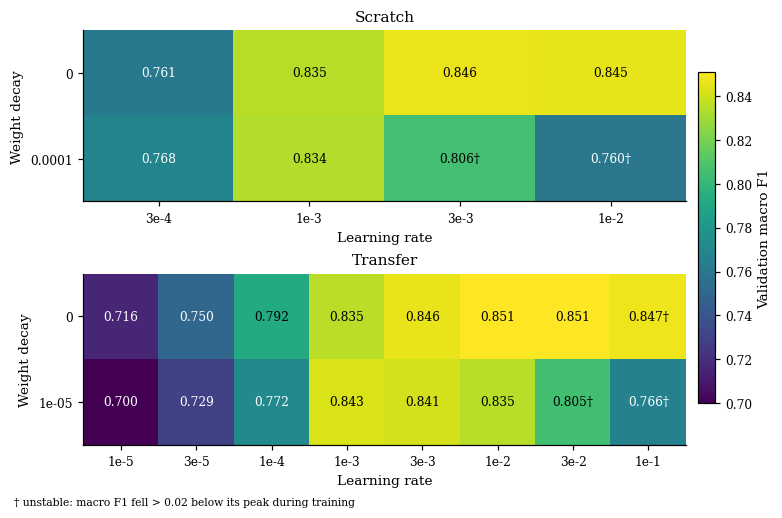

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(7, 4.6), layout="constrained")
vmin, vmax = df.macro_f1.min(), df.macro_f1.max()
for ax, v in zip(axes, ["scratch", "transfer"]):
    g = df[df.variant == v]
    piv  = g.pivot(index="wd", columns="lr", values="macro_f1")
    stab = g.pivot(index="wd", columns="lr", values="stable")
    im = ax.imshow(piv.values, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(piv.shape[1]), [lrs(x) for x in piv.columns])
    ax.set_yticks(range(piv.shape[0]), [f"{x:g}" for x in piv.index])
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            val = piv.values[i, j]
            if np.isnan(val):
                continue
            ax.text(j, i, f"{val:.3f}{'' if stab.values[i, j] else '†'}", ha="center", va="center",
                    fontsize=8, color="white" if val < (vmin + vmax) / 2 else "black")
    ax.set(title=v.capitalize(), xlabel="Learning rate", ylabel="Weight decay")
    ax.grid(False)
cb = fig.colorbar(im, ax=axes, shrink=.8, pad=.02)
cb.set_label("Validation macro F1")
fig.supxlabel(f"† unstable: macro F1 fell > {DROP_TOL} below its peak during training",
              fontsize=7, x=0.01, ha="left")

In [9]:
SEL = {}
for v, g in df.groupby("variant"):
    cand = g[g.stable]
    tied = cand[cand.macro_f1 >= cand.macro_f1.max() - TIE_F1]
    win = tied.sort_values(["interior", "lr_robust", "macro_mae_ms"],
                           ascending=[False, False, True]).iloc[0]
    SEL[v] = (tied, win)

    print(f"\n=== {v.upper()} ===")
    print("excluded (unstable):", [f"lr={lrs(a)}, wd={b:g}" for a, b in g.loc[~g.stable, ["lr", "wd"]].values])
    display(tied[["lr", "wd", "macro_f1", "macro_mae_ms", "val_loss", "best_epoch",
                  "interior", "lr_robust"]].sort_values("macro_f1", ascending=False).round(4))
    same = g[g.wd == win.wd].sort_values("lr")
    lo, hi = same[same.lr < win.lr], same[same.lr > win.lr]
    print(f"SELECTED: lr={lrs(win.lr)}, wd={win.wd:g}  macro F1={win.macro_f1:.4f}  "
          f"MAE={win.macro_mae_ms:.1f} ms  val_loss={win.val_loss:.4f}")
    print(f"  bracketing: lower neighbour F1={lo.macro_f1.iloc[-1] if len(lo) else np.nan:.4f}, "
          f"upper neighbours F1={list(hi.macro_f1.round(4))} (stable={list(hi.stable)})")

decision = pd.DataFrame({v: w for v, (_, w) in SEL.items()}).T[
    ["lr", "wd", "macro_f1", "macro_mae_ms", "val_loss", "best_epoch", "P_f1_score", "S_f1_score"]]
display(decision)
decision.to_csv(OUT / "table_selected_hyperparameters.csv")


=== SCRATCH ===
excluded (unstable): ['lr=3e-3, wd=0.0001', 'lr=1e-2, wd=0.0001']


,lr,wd,macro_f1,macro_mae_ms,val_loss,best_epoch,interior,lr_robust
4,0.003,0.0,0.8464,27.1716,0.0258,21,True,False
6,0.010,0.0,0.8454,25.9053,0.0258,20,False,False


SELECTED: lr=3e-3, wd=0  macro F1=0.8464  MAE=27.2 ms  val_loss=0.0258
  bracketing: lower neighbour F1=0.8348, upper neighbours F1=[0.8454] (stable=[True])

=== TRANSFER ===
excluded (unstable): ['lr=3e-2, wd=1e-05', 'lr=1e-1, wd=0', 'lr=1e-1, wd=1e-05']


,lr,wd,macro_f1,macro_mae_ms,val_loss,best_epoch,interior,lr_robust
20,0.030,0.0,0.8510,23.9929,0.0250,15,True,False
18,0.010,0.0,0.8506,23.6850,0.0248,25,True,True
16,0.003,0.0,0.8462,24.4921,0.0256,25,True,True


SELECTED: lr=1e-2, wd=0  macro F1=0.8506  MAE=23.7 ms  val_loss=0.0248
  bracketing: lower neighbour F1=0.8462, upper neighbours F1=[0.851, 0.8473] (stable=[True, False])


,lr,wd,macro_f1,macro_mae_ms,val_loss,best_epoch,P_f1_score,S_f1_score
scratch,0.003,0.0,0.846434,27.171592,0.025772,21,0.834744,0.858123
transfer,0.01,0.0,0.850572,23.685021,0.024831,25,0.837832,0.863313


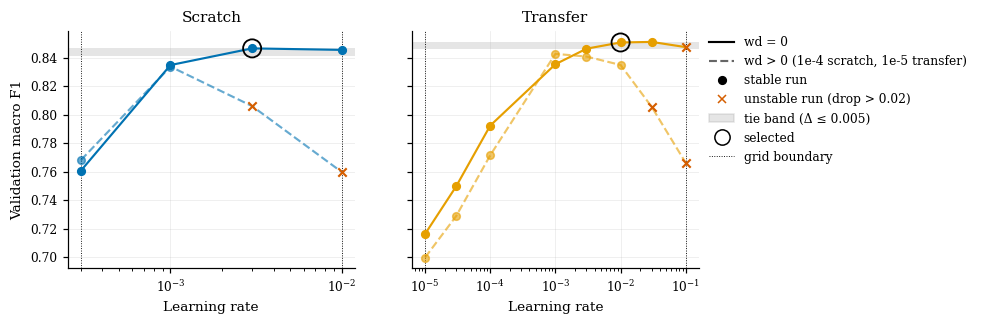

In [10]:
# ===== Cell 6: Fig 2, learning-rate response =====
fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.8), sharey=True)
for ax, v in zip(axes, ["scratch", "transfer"]):
    g = df[df.variant == v]
    tied, win = SEL[v]
    top = g[g.stable].macro_f1.max()
    ax.axhspan(top - TIE_F1, top, color=OI["grey"], alpha=.25, lw=0)
    for wd, gg in g.groupby("wd"):
        gg = gg.sort_values("lr")
        ax.plot(gg.lr, gg.macro_f1, "-" if wd == 0 else "--", color=COL[v], alpha=1 if wd == 0 else .6)
        ax.scatter(gg[gg.stable].lr, gg[gg.stable].macro_f1, color=COL[v], zorder=3,
                   alpha=1 if wd == 0 else .6)
        ax.scatter(gg[~gg.stable].lr, gg[~gg.stable].macro_f1, marker="x", color=OI["red"], s=30, zorder=4)
    ax.scatter(win.lr, win.macro_f1, s=140, facecolor="none", edgecolor="k", lw=1.2, zorder=5)
    for e in EDGES.loc[v]:
        ax.axvline(e, color="k", lw=.6, ls=":")
    ax.set(xscale="log", title=v.capitalize(), xlabel="Learning rate")
axes[0].set_ylabel("Validation macro F1")
legend_out(axes[1], handles=[
    Line2D([], [], color="k", ls="-", label="wd = 0"),
    Line2D([], [], color="k", ls="--", alpha=.6, label="wd > 0 (1e-4 scratch, 1e-5 transfer)"),
    Line2D([], [], marker="o", ls="", color="k", label="stable run"),
    Line2D([], [], marker="x", ls="", color=OI["red"], label=f"unstable run (drop > {DROP_TOL})"),
    Patch(color=OI["grey"], alpha=.25, label=f"tie band (Δ ≤ {TIE_F1})"),
    Line2D([], [], marker="o", ls="", mfc="none", mec="k", ms=10, label="selected"),
    Line2D([], [], color="k", ls=":", lw=.6, label="grid boundary"),
])

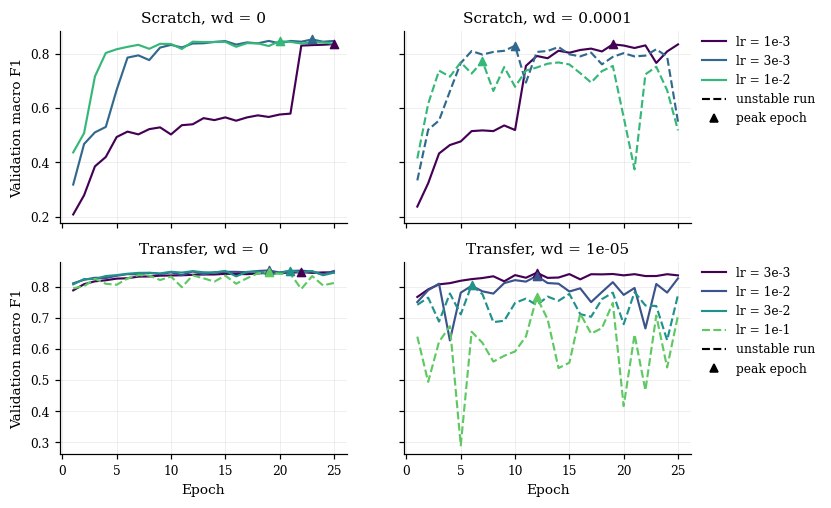

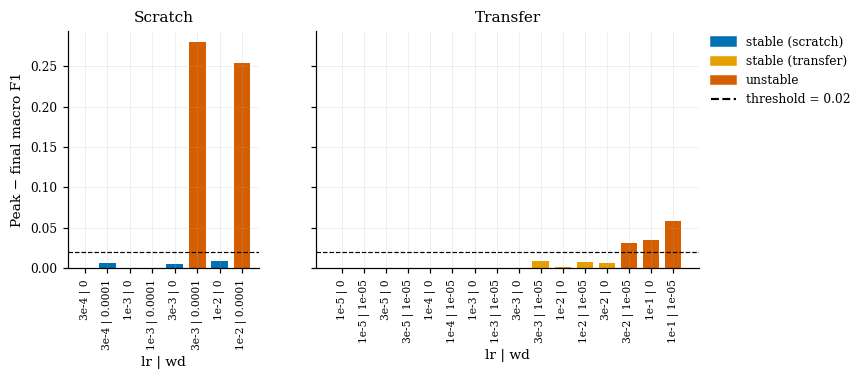

In [11]:
HIGH = {"scratch": [1e-3, 3e-3, 1e-2], "transfer": [3e-3, 1e-2, 3e-2, 1e-1]}

fig, axes = plt.subplots(2, 2, figsize=(7.4, 5.0), sharex=True, sharey="row")
for i, v in enumerate(["scratch", "transfer"]):
    g = df[df.variant == v]
    cmap = plt.get_cmap("viridis", len(HIGH[v]) + 1)
    for j, wd in enumerate(sorted(g.wd.unique())):
        ax = axes[i, j]
        for k, lr in enumerate(HIGH[v]):
            r = g[(g.lr == lr) & (g.wd == wd)]
            if r.empty:
                continue
            r = r.iloc[0]
            f = hist[r.run]["macro_f1"]; ep = np.arange(1, len(f) + 1)
            ax.plot(ep, f, color=cmap(k), ls="-" if r.stable else "--", label=f"lr = {lrs(lr)}")
            ax.scatter(r.peak_epoch, r.peak_f1, color=cmap(k), marker="^", s=28, zorder=3)
        ax.set_title(f"{v.capitalize()}, wd = {wd:g}")
        if i == 1: ax.set_xlabel("Epoch")
        if j == 0: ax.set_ylabel("Validation macro F1")
    h, l = axes[i, 0].get_legend_handles_labels()
    legend_out(axes[i, 1], handles=h + [Line2D([], [], color="k", ls="--", label="unstable run"),
                                        Line2D([], [], color="k", marker="^", ls="", label="peak epoch")])
save(fig, "fig3_learning_curves_stability")

fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.8), sharey=True,
                         gridspec_kw={"width_ratios": [(df.variant == "scratch").sum(),
                                                       (df.variant == "transfer").sum()]})
for ax, v in zip(axes, ["scratch", "transfer"]):
    g = df[df.variant == v].sort_values(["lr", "wd"])
    x = np.arange(len(g))
    ax.bar(x, g["drop"], color=[COL[v] if s else OI["red"] for s in g.stable], width=.75)
    ax.axhline(DROP_TOL, color="k", ls="--", lw=.8)
    ax.set_xticks(x, [f"{lrs(a)} | {b:g}" for a, b in zip(g.lr, g.wd)], rotation=90, fontsize=7)
    ax.set(title=v.capitalize(), xlabel="lr | wd")
axes[0].set_ylabel("Peak − final macro F1")
legend_out(axes[1], handles=[Patch(color=COL["scratch"], label="stable (scratch)"),
                             Patch(color=COL["transfer"], label="stable (transfer)"),
                             Patch(color=OI["red"], label="unstable"),
                             Line2D([], [], color="k", ls="--", label=f"threshold = {DROP_TOL}")])
save(fig, "fig4_instability")

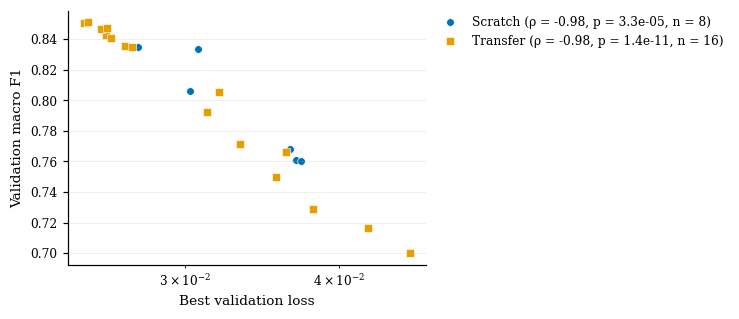

In [12]:

fig, ax = plt.subplots(figsize=(4.2, 3.0))
for v, g in df.groupby("variant"):
    rho, p = spearmanr(g.val_loss, g.macro_f1)
    ax.scatter(g.val_loss, g.macro_f1, color=COL[v], edgecolor="white", lw=.4,
               marker="o" if v == "scratch" else "s",
               label=f"{v.capitalize()} (ρ = {rho:.2f}, p = {p:.1e}, n = {len(g)})")
ax.set(xlabel="Best validation loss", ylabel="Validation macro F1", xscale="log")
legend_out(ax)
save(fig, "fig5_valloss_vs_f1")

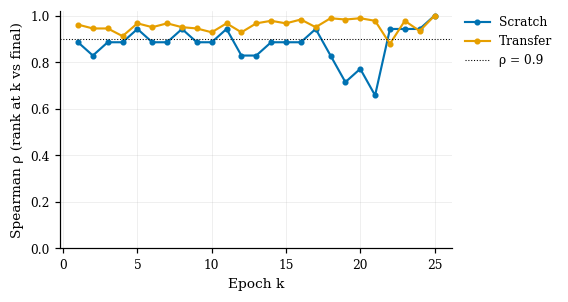

In [13]:
# ===== Cell 9: Fig 6, ranking stability (stable runs only) =====
fig, ax = plt.subplots(figsize=(4.6, 2.8))
for v, g in df[df.stable].groupby("variant"):
    n = int(g.n_epochs.min())
    final = [hist[r]["macro_f1"][n - 1] for r in g.run]
    rho = [spearmanr([hist[r]["macro_f1"][k] for r in g.run], final)[0] for k in range(n)]
    ax.plot(np.arange(1, n + 1), rho, color=COL[v], marker="o", ms=3, label=v.capitalize())
ax.axhline(0.9, color="k", ls=":", lw=.7, label="ρ = 0.9")
ax.set(xlabel="Epoch k", ylabel="Spearman ρ (rank at k vs final)", ylim=(0, 1.02))
legend_out(ax)
save(fig, "fig6_ranking_stability")

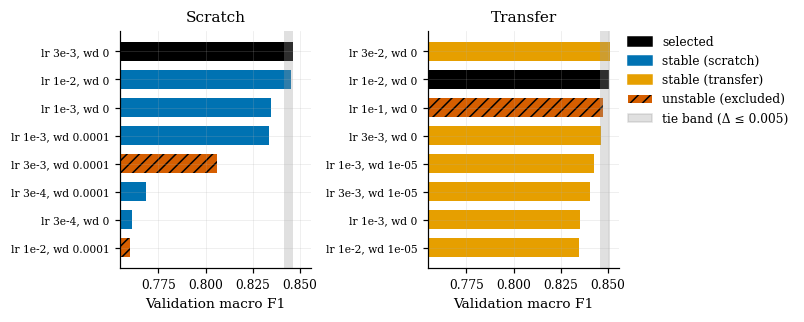

In [14]:
# ===== Cell 10: Fig 7, selection overview =====
TOP = 8
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharex=True)
for ax, v in zip(axes, ["scratch", "transfer"]):
    g = df[df.variant == v].sort_values("macro_f1", ascending=False).head(TOP)[::-1]
    tied, win = SEL[v]
    y = np.arange(len(g))
    colors = [OI["red"] if not s else ("k" if r == win.run else COL[v]) for r, s in zip(g.run, g.stable)]
    ax.barh(y, g.macro_f1, color=colors, height=.7,
            hatch=[None if s else "///" for s in g.stable])
    top = df[(df.variant == v) & df.stable].macro_f1.max()
    ax.axvspan(top - TIE_F1, top, color=OI["grey"], alpha=.3, lw=0)
    ax.set_yticks(y, [f"lr {lrs(a)}, wd {b:g}" for a, b in zip(g.lr, g.wd)], fontsize=7)
    ax.set(title=v.capitalize(), xlabel="Validation macro F1")
    ax.set_xlim(df.macro_f1.quantile(.25) - .01, df.macro_f1.max() + .005)
legend_out(axes[1], handles=[Patch(color="k", label="selected"),
                             Patch(color=COL["scratch"], label="stable (scratch)"),
                             Patch(color=COL["transfer"], label="stable (transfer)"),
                             Patch(facecolor=OI["red"], hatch="///", label="unstable (excluded)"),
                             Patch(color=OI["grey"], alpha=.3, label=f"tie band (Δ ≤ {TIE_F1})")])
fig.tight_layout()
save(fig, "fig7_selection")

model                       Global PhaseNet  Scratch (lr 3e-3)  \
metric               phase                                       
F1                   P                0.582              0.835   
                     S                0.627              0.858   
MAE (ms)             P               29.681             20.761   
                     S               57.083             33.582   
Median residual (ms) P               10.000            -10.000   
                     S               40.000              0.000   

model                       Transfer (lr 1e-2)  
metric               phase                      
F1                   P                   0.838  
                     S                   0.863  
MAE (ms)             P                  17.382  
                     S                  29.988  
Median residual (ms) P                   0.000  
                     S                   0.000

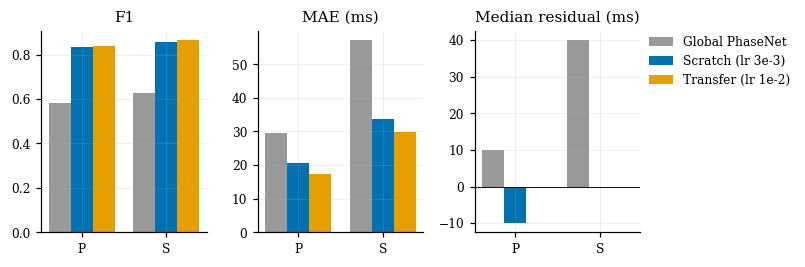

In [15]:
gl = df.dropna(subset=["GP_f1_score"]).iloc[0]
METR = [("f1_score", "F1", 1), ("mean_abs_error", "MAE (ms)", 1000), ("median_difference", "Median residual (ms)", 1000)]
models = {"Global PhaseNet": (lambda ph, k: gl[f"G{ph}_{k}"], COL["global"])}
for v in ["scratch", "transfer"]:
    w = SEL[v][1]
    models[f"{v.capitalize()} (lr {lrs(w.lr)})"] = ((lambda w: lambda ph, k: w[f"{ph}_{k}"])(w), COL[v])

fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.5))
x, width = np.arange(2), .26
rows_out = []
for ax, (k, lab, scale) in zip(axes, METR):
    for i, (m, (get, c)) in enumerate(models.items()):
        vals = [get(ph, k) * scale for ph in "PS"]
        ax.bar(x + (i - 1) * width, vals, width, color=c, label=m)
        rows_out += [dict(model=m, phase=ph, metric=lab, value=val) for ph, val in zip("PS", vals)]
    ax.set_xticks(x, ["P", "S"]); ax.set_title(lab); ax.axhline(0, color="k", lw=.6)
legend_out(axes[-1])
fig.tight_layout()
save(fig, "fig8_local_vs_global")
comp = pd.DataFrame(rows_out).pivot_table(index=["metric", "phase"], columns="model", values="value")
display(comp.round(3)); comp.to_csv(OUT / "table_local_vs_global_validation.csv")